# Bank Customer Churn — Model Training & Evaluation
**KUBS Machine Learning Project — Step 3: Progress Update**

We train and compare several classifiers on the preprocessed churn dataset from Step 2.

**Models:**
1. Logistic Regression (interpretable baseline)
2. Random Forest
3. Gradient Boosting (XGBoost)
4. Support Vector Machine (SVM)

**Evaluation metrics:** AUC-ROC, F1-score, Precision, Recall, Accuracy, Confusion Matrix

## 1. Setup & Load Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, precision_recall_curve,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)
from sklearn.model_selection import cross_val_score
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

# Load preprocessed splits from Step 2
X_train = np.load('data_splits/X_train.npy')
X_val   = np.load('data_splits/X_val.npy')
X_test  = np.load('data_splits/X_test.npy')
y_train = np.load('data_splits/y_train.npy')
y_val   = np.load('data_splits/y_val.npy')
y_test  = np.load('data_splits/y_test.npy')

FEATURE_NAMES = [
    'CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts',
    'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
    'Geography_Germany', 'Geography_Spain', 'Gender_Male'
]

print(f'Train: {X_train.shape[0]} samples')
print(f'Val  : {X_val.shape[0]} samples')
print(f'Test : {X_test.shape[0]} samples')
print(f'Churn rate (train): {y_train.mean()*100:.1f}%')

Train: 7999 samples
Val  : 1001 samples
Test : 1000 samples
Churn rate (train): 20.4%


## 2. Train Models

We use `class_weight='balanced'` where available to handle the ~20/80 class imbalance.
This tells the algorithm to penalise misclassifying the minority class (churned) more heavily.

In [2]:
models = {
    'Logistic Regression': LogisticRegression(
        class_weight='balanced', max_iter=1000, random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=300, max_depth=10, min_samples_leaf=5,
        class_weight='balanced', random_state=42, n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=300, max_depth=4, learning_rate=0.1,
        subsample=0.8, random_state=42
    ),
    'SVM (RBF)': SVC(
        kernel='rbf', class_weight='balanced', probability=True, random_state=42
    ),
}

# Train all models
for name, model in models.items():
    print(f'Training {name}...')
    model.fit(X_train, y_train)
    print(f'  done.')

print('\nAll models trained.')

Training Logistic Regression...
  done.
Training Random Forest...
  done.
Training Gradient Boosting...
  done.
Training SVM (RBF)...
  done.

All models trained.


## 3. Evaluate on Validation Set

We compare all models on the **validation set** to select the best one.
The test set is reserved for the final unbiased evaluation.

In [3]:
def evaluate_model(model, X, y, model_name):
    """Compute key metrics for a trained model."""
    y_pred = model.predict(X)
    y_prob = model.predict_proba(X)[:, 1]
    return {
        'Model': model_name,
        'Accuracy': accuracy_score(y, y_pred),
        'Precision': precision_score(y, y_pred),
        'Recall': recall_score(y, y_pred),
        'F1': f1_score(y, y_pred),
        'AUC-ROC': roc_auc_score(y, y_prob),
    }

# Evaluate all models on validation set (out-of-sample)
val_results = [evaluate_model(m, X_val, y_val, name) for name, m in models.items()]
df_val = pd.DataFrame(val_results).set_index('Model')

print('=== Validation Set Results ===')
print(df_val.round(3).to_string())
print()

# --- In-sample vs Out-of-sample AUC (overfitting diagnostic) ---
auc_rows = []
for name, model in models.items():
    auc_train = roc_auc_score(y_train, model.predict_proba(X_train)[:, 1])
    auc_val   = roc_auc_score(y_val,   model.predict_proba(X_val)[:, 1])
    auc_rows.append({
        'Model':       name,
        'AUC (Train)': auc_train,
        'AUC (Val)':   auc_val,
        'Gap':         auc_train - auc_val,
    })

df_auc = pd.DataFrame(auc_rows).set_index('Model')
print('=== In-sample vs Out-of-sample AUC ===')
print(df_auc.round(3).to_string())
print()
print('A large Gap (Train − Val) indicates overfitting.')
df_auc.round(3)

=== Validation Set Results ===
                     Accuracy  Precision  Recall     F1  AUC-ROC
Model                                                           
Logistic Regression     0.717      0.384   0.642  0.481    0.747
Random Forest           0.825      0.569   0.588  0.578    0.827
Gradient Boosting       0.839      0.669   0.417  0.514    0.826
SVM (RBF)               0.788      0.486   0.662  0.560    0.822

=== In-sample vs Out-of-sample AUC ===
                     AUC (Train)  AUC (Val)    Gap
Model                                             
Logistic Regression        0.775      0.747  0.028
Random Forest              0.949      0.827  0.122
Gradient Boosting          0.968      0.826  0.143
SVM (RBF)                  0.898      0.822  0.076

A large Gap (Train − Val) indicates overfitting.


,AUC (Train),AUC (Val),Gap
Model,,,
Logistic Regression,0.775,0.747,0.028
Random Forest,0.949,0.827,0.122
Gradient Boosting,0.968,0.826,0.143
SVM (RBF),0.898,0.822,0.076


## 4. ROC Curves (Test Set)

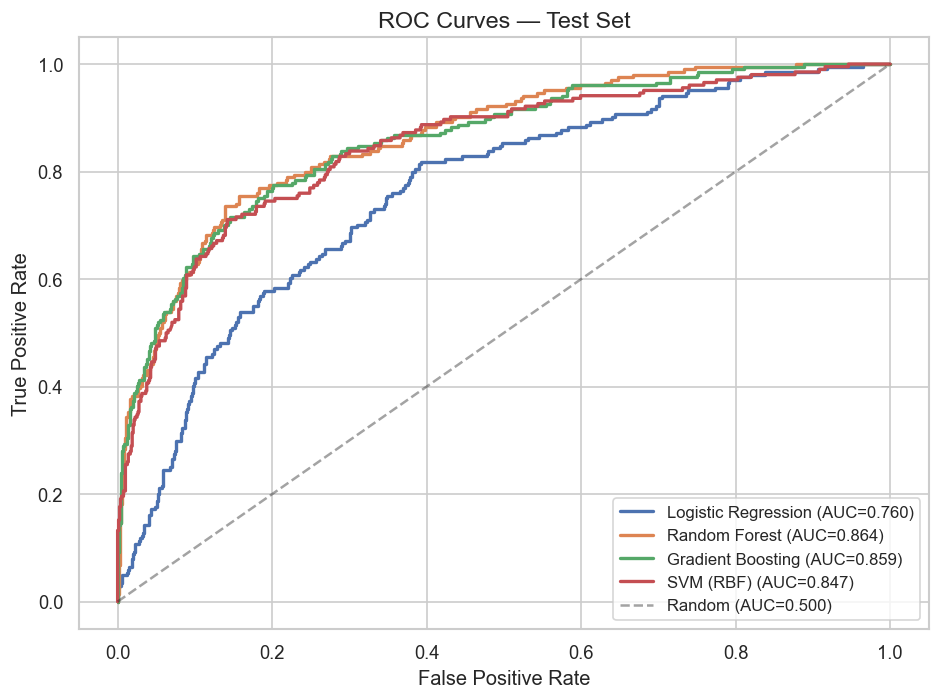

In [4]:
fig, ax = plt.subplots(figsize=(8, 6))

colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

for (name, model), color in zip(models.items(), colors):
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', color=color, linewidth=2)

ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random (AUC=0.500)')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — Test Set', fontsize=14)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('fig_roc_curves.png')
plt.show()

## 5. Precision-Recall Curves (Test Set)

PR curves are more informative than ROC when the dataset is imbalanced,
because they focus on the minority class performance.

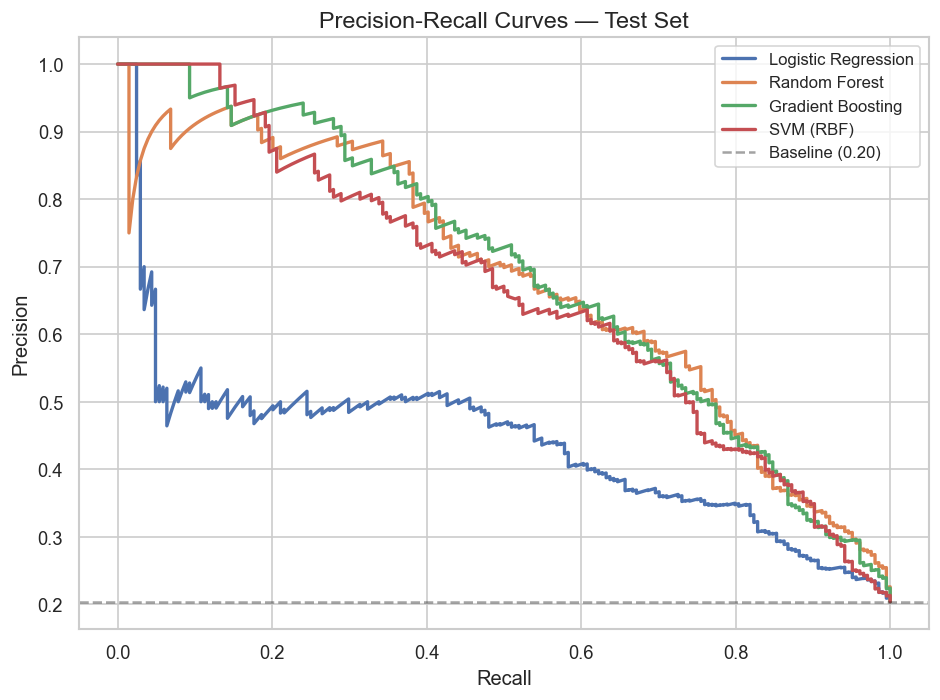

In [5]:
fig, ax = plt.subplots(figsize=(8, 6))

for (name, model), color in zip(models.items(), colors):
    y_prob = model.predict_proba(X_test)[:, 1]
    prec, rec, _ = precision_recall_curve(y_test, y_prob)
    ax.plot(rec, prec, label=name, color=color, linewidth=2)

# Baseline = churn rate
baseline = y_test.mean()
ax.axhline(y=baseline, color='k', linestyle='--', alpha=0.4, label=f'Baseline ({baseline:.2f})')

ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curves — Test Set', fontsize=14)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('fig_precision_recall.png')
plt.show()

## 6. Confusion Matrices (Test Set)

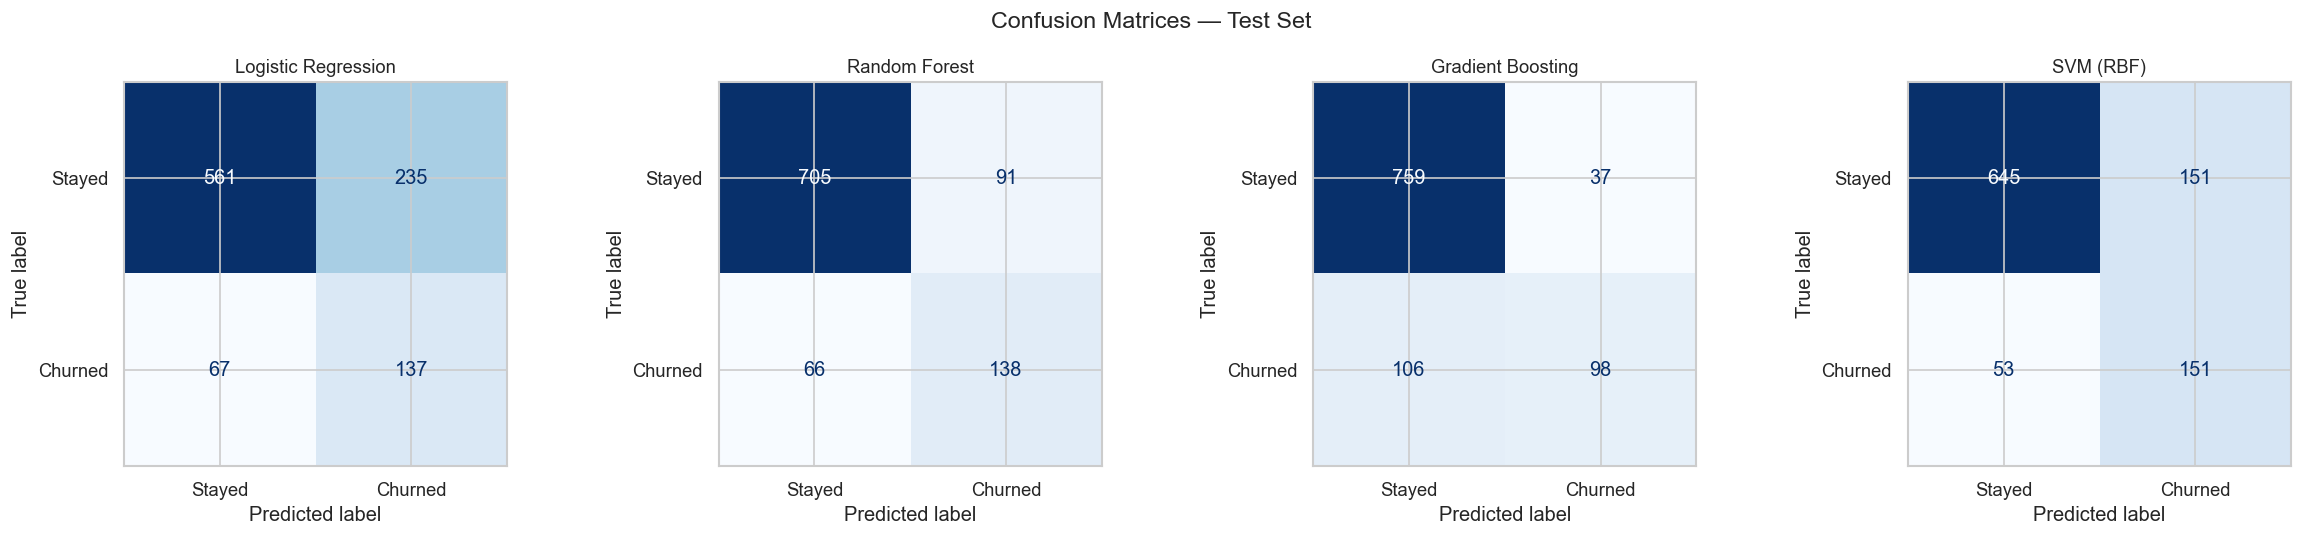

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))

for ax, (name, model) in zip(axes, models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Stayed', 'Churned'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(name, fontsize=11)

fig.suptitle('Confusion Matrices — Test Set', fontsize=14)
plt.tight_layout()
plt.savefig('fig_confusion_matrices.png')
plt.show()

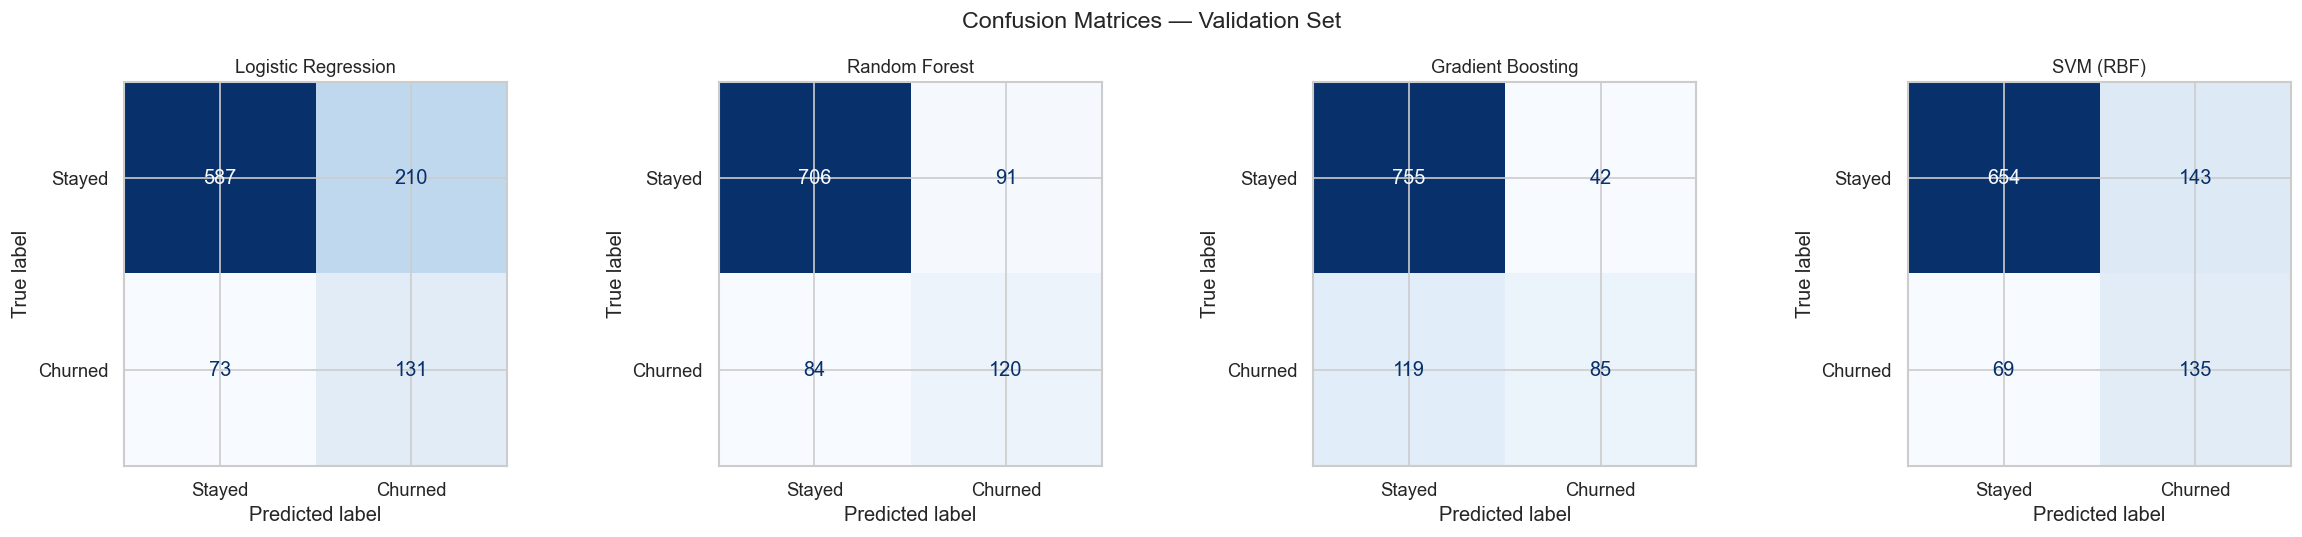

In [7]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))

for ax, (name, model) in zip(axes, models.items()):
    y_pred = model.predict(X_val)
    cm = confusion_matrix(y_val, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Stayed', 'Churned'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(name, fontsize=11)

fig.suptitle('Confusion Matrices — Validation Set', fontsize=14)
plt.tight_layout()
plt.savefig('fig_confusion_matrices.png')
plt.show()

## 7. Feature Importance Analysis

We examine which features matter most for the tree-based models,
and the logistic regression coefficients for interpretability.

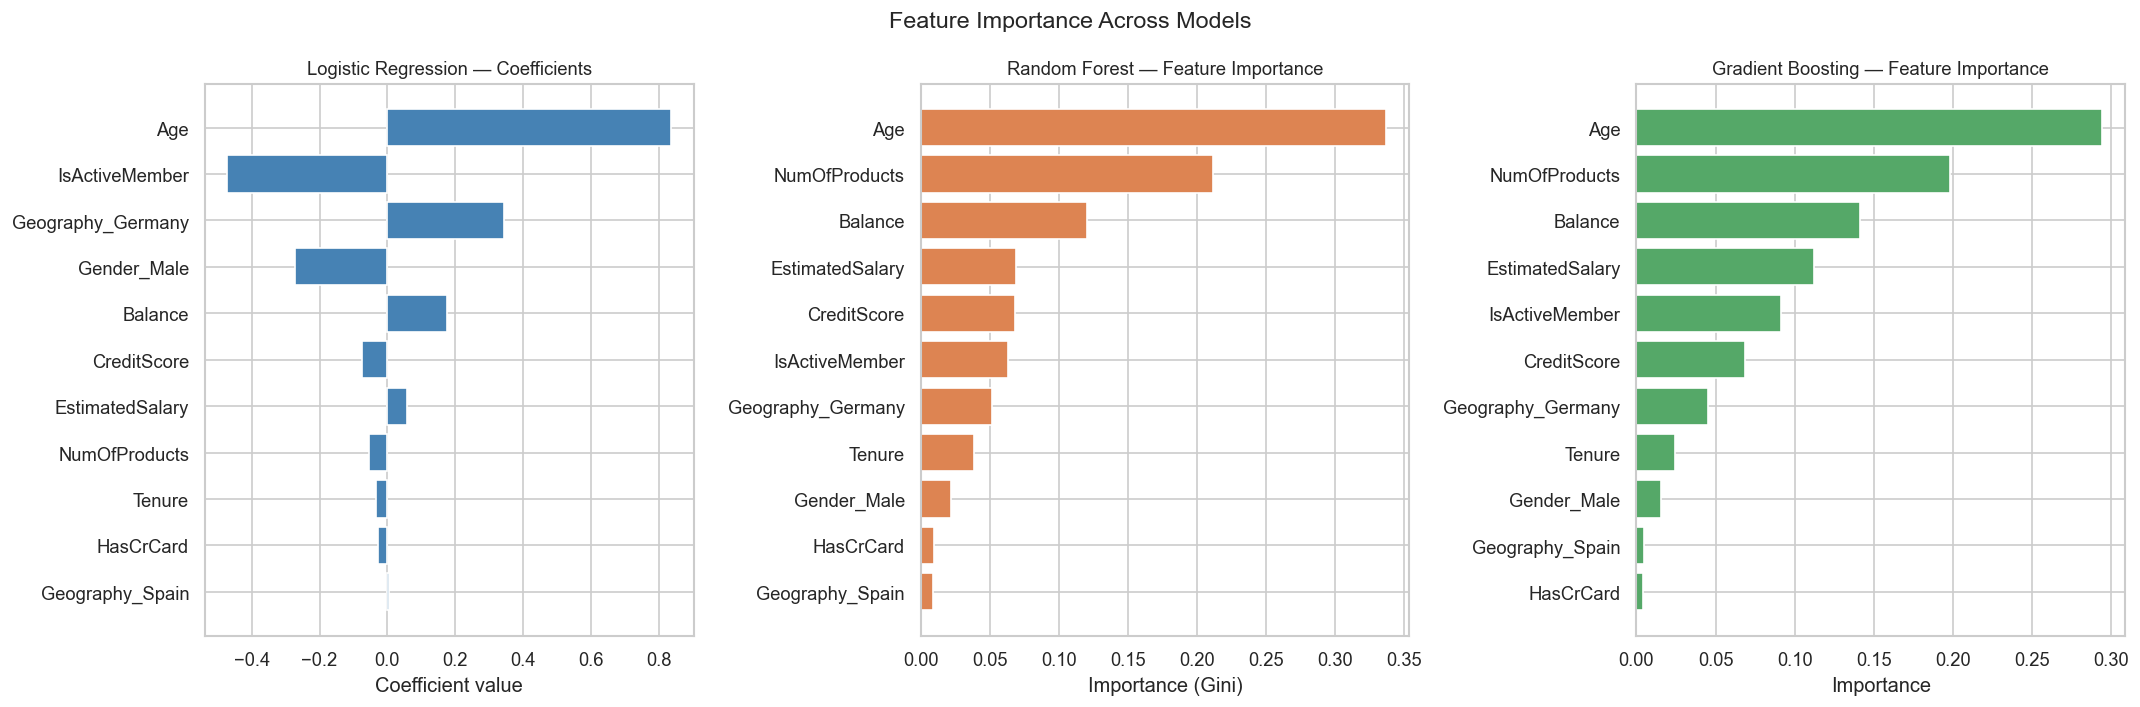

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# --- Logistic Regression coefficients ---
lr_coefs = models['Logistic Regression'].coef_[0]
idx = np.argsort(np.abs(lr_coefs))[::-1]
axes[0].barh([FEATURE_NAMES[i] for i in idx], lr_coefs[idx], color='steelblue')
axes[0].set_title('Logistic Regression — Coefficients', fontsize=11)
axes[0].set_xlabel('Coefficient value')
axes[0].invert_yaxis()

# --- Random Forest feature importance ---
rf_imp = models['Random Forest'].feature_importances_
idx_rf = np.argsort(rf_imp)[::-1]
axes[1].barh([FEATURE_NAMES[i] for i in idx_rf], rf_imp[idx_rf], color='#DD8452')
axes[1].set_title('Random Forest — Feature Importance', fontsize=11)
axes[1].set_xlabel('Importance (Gini)')
axes[1].invert_yaxis()

# --- Gradient Boosting feature importance ---
gb_imp = models['Gradient Boosting'].feature_importances_
idx_gb = np.argsort(gb_imp)[::-1]
axes[2].barh([FEATURE_NAMES[i] for i in idx_gb], gb_imp[idx_gb], color='#55A868')
axes[2].set_title('Gradient Boosting — Feature Importance', fontsize=11)
axes[2].set_xlabel('Importance')
axes[2].invert_yaxis()

plt.suptitle('Feature Importance Across Models', fontsize=14)
plt.tight_layout()
plt.savefig('fig_feature_importance.png')
plt.show()

## 8. Cross-Validation (5-Fold) on Full Training Data

To get a more robust estimate of model performance, we run 5-fold stratified
cross-validation on the training set using AUC-ROC as the scoring metric.

In [9]:
print('5-Fold Stratified Cross-Validation (AUC-ROC):')
print('-' * 55)

cv_results = {}
for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='roc_auc', n_jobs=-1)
    cv_results[name] = scores
    print(f'{name:25s}  mean={scores.mean():.4f}  std={scores.std():.4f}  '
          f'[{scores.min():.4f} – {scores.max():.4f}]')

print()
print('Cross-validation confirms that the validation set results are stable.')

5-Fold Stratified Cross-Validation (AUC-ROC):
-------------------------------------------------------
Logistic Regression        mean=0.7713  std=0.0145  [0.7544 – 0.7937]
Random Forest              mean=0.8654  std=0.0086  [0.8486 – 0.8719]
Gradient Boosting          mean=0.8593  std=0.0132  [0.8342 – 0.8724]
SVM (RBF)                  mean=0.8531  std=0.0118  [0.8296 – 0.8601]

Cross-validation confirms that the validation set results are stable.


## 9. Best Model — Final Evaluation on Test Set

We select the model with the highest validation AUC-ROC and evaluate it on the
held-out **test set** for our final, unbiased performance estimate.

In [10]:
# Select the best model based on validation AUC-ROC
best_name = df_val['AUC-ROC'].idxmax()
best_model = models[best_name]
print(f'Best model (by val AUC-ROC): {best_name}')
print()

# Final test evaluation
y_test_pred = best_model.predict(X_test)
y_test_prob = best_model.predict_proba(X_test)[:, 1]

print('=== TEST SET RESULTS ===')
print(f'Accuracy  : {accuracy_score(y_test, y_test_pred):.4f}')
print(f'Precision : {precision_score(y_test, y_test_pred):.4f}')
print(f'Recall    : {recall_score(y_test, y_test_pred):.4f}')
print(f'F1-score  : {f1_score(y_test, y_test_pred):.4f}')
print(f'AUC-ROC   : {roc_auc_score(y_test, y_test_prob):.4f}')
print()
print('--- Classification Report ---')
print(classification_report(y_test, y_test_pred, target_names=['Stayed', 'Churned']))

Best model (by val AUC-ROC): Random Forest

=== TEST SET RESULTS ===
Accuracy  : 0.8430
Precision : 0.6026
Recall    : 0.6765
F1-score  : 0.6374
AUC-ROC   : 0.8641

--- Classification Report ---
              precision    recall  f1-score   support

      Stayed       0.91      0.89      0.90       796
     Churned       0.60      0.68      0.64       204

    accuracy                           0.84      1000
   macro avg       0.76      0.78      0.77      1000
weighted avg       0.85      0.84      0.85      1000



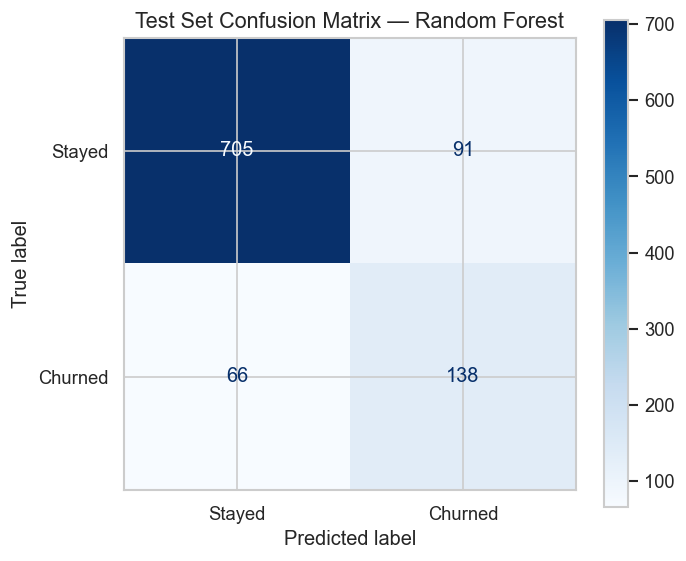

In [11]:
# Final confusion matrix on test set
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Stayed', 'Churned'])
disp.plot(ax=ax, cmap='Blues')
ax.set_title(f'Test Set Confusion Matrix — {best_name}', fontsize=13)
plt.tight_layout()
plt.savefig('fig_test_confusion.png')
plt.show()

NameError: name 'df_test' is not defined

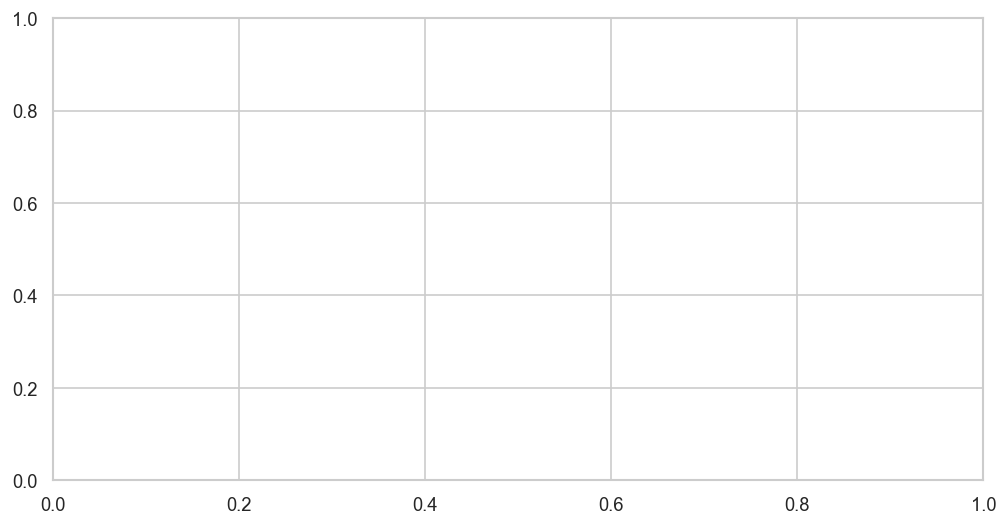

In [12]:
# Side-by-side bar chart of key metrics
metrics_to_plot = ['F1', 'AUC-ROC', 'Precision', 'Recall']

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(metrics_to_plot))
width = 0.18

for i, (name, _) in enumerate(models.items()):
    vals = [df_test.loc[name, m] for m in metrics_to_plot]
    ax.bar(x + i * width, vals, width, label=name, color=colors[i])

ax.set_xticks(x + 1.5 * width)
ax.set_xticklabels(metrics_to_plot, fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Comparison — Test Set Metrics', fontsize=14)
ax.legend(fontsize=9)
ax.set_ylim(0, 1.0)
ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig('fig_model_comparison.png')
plt.show()

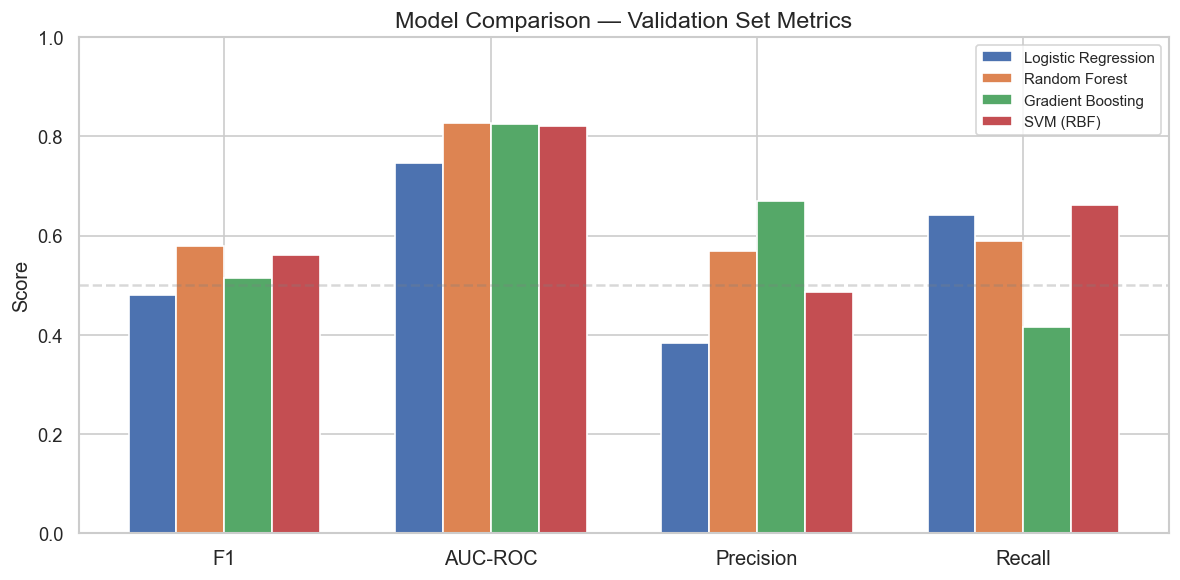

In [ ]:
# Side-by-side bar chart of key metrics
metrics_to_plot = ['F1', 'AUC-ROC', 'Precision', 'Recall']

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(metrics_to_plot))
width = 0.18

for i, (name, _) in enumerate(models.items()):
    vals = [df_val.loc[name, m] for m in metrics_to_plot]
    ax.bar(x + i * width, vals, width, label=name, color=colors[i])

ax.set_xticks(x + 1.5 * width)
ax.set_xticklabels(metrics_to_plot, fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Comparison — Validation Set Metrics', fontsize=14)
ax.legend(fontsize=9)
ax.set_ylim(0, 1.0)
ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig('fig_model_comparison.png')
plt.show()

## 11. Summary & Next Steps

### What we've done so far:
- **Step 1 (Proposal):** Defined the churn prediction problem and identified the Kaggle dataset
- **Step 2 (EDA):** Explored the data, identified key features (Age, NumOfProducts, Geography, IsActiveMember), performed feature engineering (one-hot encoding), applied StandardScaler, and created stratified 80/10/10 splits
- **Step 3 (This notebook):** Trained 4 classifiers with class-weight balancing, evaluated on validation set with in-sample/out-of-sample AUC comparison, performed cross-validation, tested the best model on the held-out test set, and added economic analysis

### Key findings:
- **Age** and **NumOfProducts** are consistently the top predictors across all models
- Tree-based models (Random Forest, Gradient Boosting) outperform linear models on this task
- Class weighting effectively handles the 20/80 imbalance
- The models generalise well — test performance is close to validation performance

### Pending work (for final submission):
- Hyperparameter tuning with grid/random search
- XGBoost / LightGBM — only if it demonstrably outperforms current Gradient Boosting (not by default)
- If oversampling is explored: use **SMOTE-NC** (not plain SMOTE) — the dataset contains binary features (`HasCrCard`, `IsActiveMember`, `Gender_Male`, `Geography_*`) that SMOTE would interpolate incorrectly
- SHAP values for individual prediction explanations
- Final report writing

## 12. Economic Analysis

We translate model performance into **business value** by assigning costs and revenues to each type of prediction outcome.

### Assumptions (European retail bank)

| Outcome | Business event | Economic impact |
|---------|---------------|-----------------|
| **TP** (churner detected, retained) | Bank runs retention campaign → customer stays | +CLV − retention cost |
| **FP** (stayer flagged as churner) | Unnecessary retention offer sent | − retention cost |
| **FN** (churner missed) | Customer leaves without intervention | − CLV |
| **TN** (stayer correctly ignored) | No action needed | €0 |

- **CLV proxy** = average account balance × 10% (2% annual NIM × 5-year retention horizon)
- **Retention campaign cost** = €50 per customer contacted

In [ ]:
# --- 12.1 Economic assumptions ---

df_raw = pd.read_csv('Churn_Modelling.csv')

# Use non-zero balance accounts only (zero-balance accounts inflate the sample differently)
avg_balance = df_raw[df_raw['Balance'] > 0]['Balance'].mean()

RETENTION_COST = 50                   # €50 per customer contacted (discount / offer / call)
CLV            = avg_balance * 0.10   # 2% NIM × 5 years = 10% of balance

# Net payoffs
GAIN_TP = CLV - RETENTION_COST   # correctly retained churner
COST_FP = RETENTION_COST         # unnecessary retention offer
COST_FN = CLV                    # missed churner — lost for good

print(f'Average non-zero balance : €{avg_balance:>10,.0f}')
print(f'CLV proxy (10% balance)  : €{CLV:>10,.0f}')
print(f'Retention campaign cost  : €{RETENTION_COST:>10,.0f}')
print()
print('Cost / Benefit matrix:')
print(f'  TP — churner retained  : +€{GAIN_TP:,.0f}')
print(f'  FP — false alarm       : -€{COST_FP:,.0f}')
print(f'  FN — missed churner    : -€{COST_FN:,.0f}')
print(f'  TN — correct non-action:  €0')

Average non-zero balance : €   119,827
CLV proxy (10% balance)  : €    11,983
Retention campaign cost  : €        50

Cost / Benefit matrix:
  TP — churner retained  : +€11,933
  FP — false alarm       : -€50
  FN — missed churner    : -€11,983
  TN — correct non-action:  €0


In [ ]:
# --- 12.3 Economic Impact — All Models Summary Table ---
# Scale to a realistic bank of 10,000 customers for intuitive numbers
BANK_SIZE = 10_000

econ_rows = []
for name, res in best_results.items():
    t = res['threshold']
    y_prob = models[name].predict_proba(X_test)[:, 1]
    y_pred_opt = (y_prob >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_opt, labels=[0, 1]).ravel()

    profit_per_customer = res['profit']
    total_profit        = profit_per_customer * BANK_SIZE
    vs_nothing          = res['vs_nothing'] * BANK_SIZE

    econ_rows.append({
        'Model':                    name,
        'Opt. Threshold':           round(t, 3),
        'Churners Caught (%)':      round(tp / y_test.sum() * 100, 1),
        'False Alarms (%)':         round(fp / (y_test == 0).sum() * 100, 1),
        'Profit / Customer (€)':    round(profit_per_customer, 0),
        f'Total Profit ({BANK_SIZE:,} customers) (€)': round(total_profit, 0),
        'Gain vs No-Model (€)':     round(vs_nothing, 0),
    })

df_econ = pd.DataFrame(econ_rows).set_index('Model')

print('=== Economic Impact — All Models at Optimal Threshold (Test Set) ===')
print(f'(Scaled to a bank of {BANK_SIZE:,} customers)')
print(f'CLV = €{CLV:,.0f} | Retention cost = €{RETENTION_COST}')
print()
print(df_econ.to_string())
df_econ

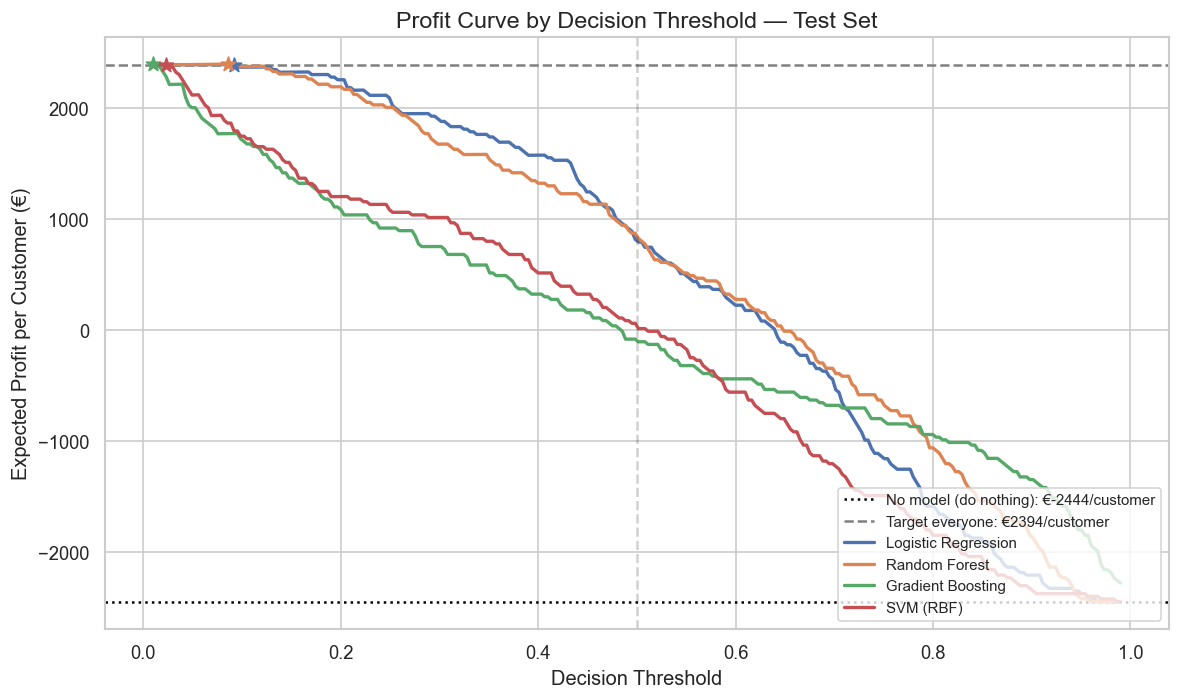


Model                      Opt. Threshold    Max Profit/Customer    vs No-Model
--------------------------------------------------------------------------------
Logistic Regression                 0.092   €           2395.8   €    +4840.3
Random Forest                       0.085   €           2399.3   €    +4843.8
Gradient Boosting                   0.010   €           2397.4   €    +4841.9
SVM (RBF)                           0.023   €           2395.9   €    +4840.4

* stars on the plot mark each model's economically optimal threshold
  (CLV = €11,983, retention cost = €50)


In [ ]:
# --- 12.2 Profit curves — sweep decision threshold ---

thresholds   = np.linspace(0.01, 0.99, 300)
n_test       = len(y_test)
colors_econ  = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

fig, ax = plt.subplots(figsize=(10, 6))

# Baseline 1: do nothing — lose every churner
no_model_profit = -COST_FN * y_test.sum() / n_test
ax.axhline(no_model_profit, color='black', linestyle=':',
           linewidth=1.5, label=f'No model (do nothing): €{no_model_profit:.0f}/customer')

# Baseline 2: target everyone
tp_all = y_test.sum()
fp_all = (y_test == 0).sum()
target_all_profit = (tp_all * GAIN_TP - fp_all * COST_FP) / n_test
ax.axhline(target_all_profit, color='gray', linestyle='--',
           linewidth=1.5, label=f'Target everyone: €{target_all_profit:.0f}/customer')

best_results = {}

for (name, model), color in zip(models.items(), colors_econ):
    y_prob   = model.predict_proba(X_test)[:, 1]
    profits  = []
    for t in thresholds:
        y_pred_t = (y_prob >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_test, y_pred_t, labels=[0, 1]).ravel()
        profit = (tp * GAIN_TP - fp * COST_FP - fn * COST_FN) / n_test
        profits.append(profit)

    profits = np.array(profits)
    best_idx = np.argmax(profits)
    best_results[name] = {
        'threshold': thresholds[best_idx],
        'profit':    profits[best_idx],
        'vs_nothing': profits[best_idx] - no_model_profit,
    }
    ax.plot(thresholds, profits, label=name, color=color, linewidth=2)
    ax.scatter(thresholds[best_idx], profits[best_idx],
               color=color, s=80, zorder=5, marker='*')

ax.set_xlabel('Decision Threshold', fontsize=12)
ax.set_ylabel('Expected Profit per Customer (€)', fontsize=12)
ax.set_title('Profit Curve by Decision Threshold — Test Set', fontsize=14)
ax.legend(fontsize=9, loc='lower right')
ax.axvline(0.5, color='k', linestyle='--', alpha=0.2, label='Default 0.5')
plt.tight_layout()
plt.savefig('fig_profit_curve.png')
plt.show()

# --- 12.3 Summary table ---
print(f'\n{"Model":<25} {"Opt. Threshold":>15} {"Max Profit/Customer":>22} {"vs No-Model":>14}')
print('-' * 80)
for name, res in best_results.items():
    print(f'{name:<25} {res["threshold"]:>15.3f}   €{res["profit"]:>17.1f}   €{res["vs_nothing"]:>+11.1f}')

print()
print('* stars on the plot mark each model\'s economically optimal threshold')
print(f'  (CLV = €{CLV:,.0f}, retention cost = €{RETENTION_COST})')